In [ ]:
!pip install -q \
transformers==4.43.3 \
datasets==2.21.0 \
accelerate==0.33.0 \
tokenizers==0.19.1 \
huggingface_hub==0.24.6

In [1]:
import transformers
import datasets

print(transformers.__version__)
print(datasets.__version__)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

4.43.3
2.21.0


In [2]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [4]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer

from collections import Counter

In [5]:
dataset = load_dataset("dair-ai/emotion")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [6]:
print(dataset["train"][0])
# Convert training split to pandas DataFrame
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

# Display first 5 rows
train_df.head()

{'text': 'i didnt feel humiliated', 'label': 0}


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [7]:
label_names = dataset["train"].features["label"].names

print(label_names)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [8]:
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

print(id2label)

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [9]:
print("Training examples:", len(train_df))
print("Validation examples:", len(val_df))
print("Test examples:", len(test_df))

Training examples: 16000
Validation examples: 2000
Test examples: 2000


In [10]:
# Count class frequencies in training set
class_counts = train_df["label"].value_counts().sort_index()

# Replace numeric labels with text labels
class_counts.index = [id2label[i] for i in class_counts.index]

print(class_counts)

sadness     4666
joy         5362
love        1304
anger       2159
fear        1937
surprise     572
Name: count, dtype: int64


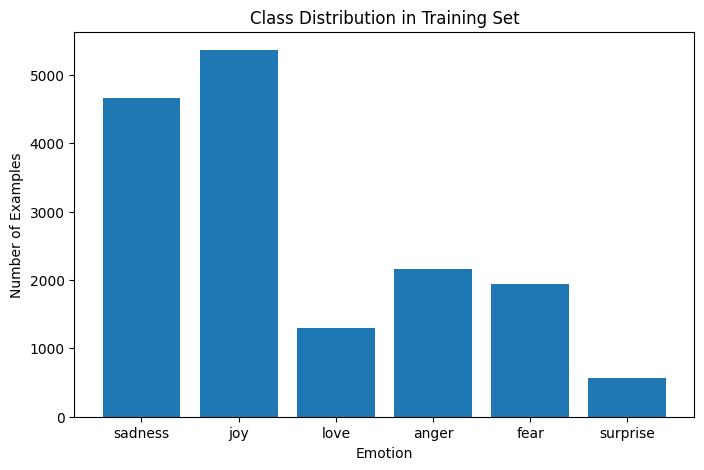

In [11]:
#visualized class distribution
plt.figure(figsize=(8,5))
plt.bar(class_counts.index, class_counts.values)

plt.title("Class Distribution in Training Set")
plt.xlabel("Emotion")
plt.ylabel("Number of Examples")

plt.show()

In [12]:
train_df["token_length"] = train_df["text"].apply(lambda x: len(x.split()))

print(train_df["token_length"].describe())

count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: token_length, dtype: float64


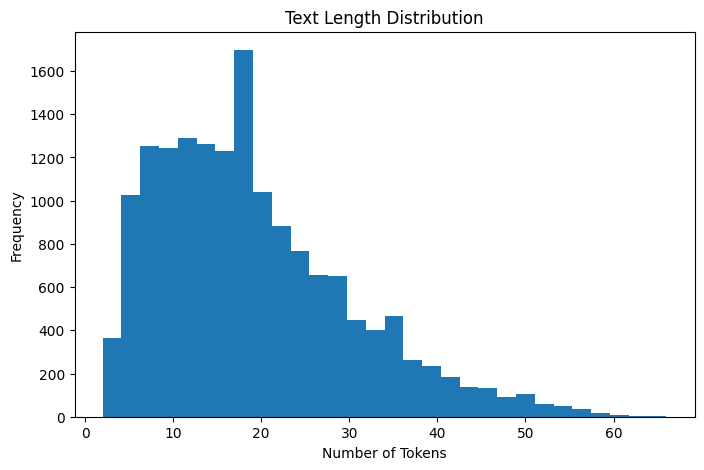

In [13]:
plt.figure(figsize=(8,5))
plt.hist(train_df["token_length"], bins=30)

plt.title("Text Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")

plt.show()

In [14]:
def custom_tokenizer(text):
    return text.lower().split()

In [15]:
counter = Counter()

for text in train_df["text"]:
    counter.update(custom_tokenizer(text))

# word -> integer mapping
vocab_obj = {
    word: idx + 2
    for idx, (word, _) in enumerate(counter.items())
}

# special tokens
vocab_obj["<pad>"] = 0
vocab_obj["<unk>"] = 1

print("Vocabulary size:", len(vocab_obj))

Vocabulary size: 15214


In [16]:
def encode_text(text):

    tokens = custom_tokenizer(text)

    return [
        vocab_obj.get(token, vocab_obj["<unk>"])
        for token in tokens
    ]

In [17]:
MAX_LENGTH = 40

PAD_IDX = vocab_obj["<pad>"]

def pad_sequence(sequence, max_length=MAX_LENGTH):

    sequence = sequence[:max_length]

    if len(sequence) < max_length:
        sequence += [PAD_IDX] * (
            max_length - len(sequence)
        )

    return sequence

In [18]:
sample = encode_text(train_df["text"][0])

print("Original length:", len(sample))

padded = pad_sequence(sample)

print("Padded length:", len(padded))

print(padded)

Original length: 4
Padded length: 40
[2, 3, 4, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [19]:
transformer_tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [20]:
sample_text = train_df["text"][0]

encoded = transformer_tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=64
)

print(encoded)

{'input_ids': [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


In [21]:
# CLEANING

# Remove leading/trailing spaces
train_df["text"] = train_df["text"].str.strip()
val_df["text"] = val_df["text"].str.strip()
test_df["text"] = test_df["text"].str.strip()

# Lowercase only for custom RNN pipeline
train_df["text"] = train_df["text"].str.lower()
val_df["text"] = val_df["text"].str.lower()
test_df["text"] = test_df["text"].str.lower()

## Part 1 — Preprocessing Justification

**Lowercasing**: Applied only to RNN. Reduces vocab sparsity. DistilBERT tokenizer handles it.

**Punctuation**: Kept. Carries emotion signal.

**Max length**: 40 for RNN, 64 for BERT.

**Whitespace**: Stripped universally.

RNN from scratch

In [22]:
# Enocoded datasets

train_sequences = [
    pad_sequence(encode_text(text))
    for text in train_df["text"]
]

val_sequences = [
    pad_sequence(encode_text(text))
    for text in val_df["text"]
]

test_sequences = [
    pad_sequence(encode_text(text))
    for text in test_df["text"]
]

In [23]:
# Convert labels
train_labels = train_df["label"].values
val_labels = val_df["label"].values
test_labels = test_df["label"].values

In [25]:
X_train = torch.tensor(train_sequences)
X_val = torch.tensor(val_sequences)
X_test = torch.tensor(test_sequences)

y_train = torch.tensor(train_labels)
y_val = torch.tensor(val_labels)
y_test = torch.tensor(test_labels)

In [26]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

In [27]:
#Hyperparameters

EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_CLASSES = 6

In [28]:
print(X_train.shape)

torch.Size([16000, 40])


RNN GRU

In [29]:
import torch.nn as nn

In [31]:
class GRUClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes
    ):

        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_IDX
        )

        # GRU layer
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # Dropout
        self.dropout = nn.Dropout(0.3)

        # Final classifier
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):

        embedded = self.embedding(x)

        output, hidden = self.gru(embedded)

        # The hidden state at the last time step is often used for classification
        # hidden has shape (num_layers * num_directions, batch_size, hidden_size)
        # For a simple GRU, num_layers=1, num_directions=1, so we squeeze dimension 0
        hidden = hidden.squeeze(0)

        hidden = self.dropout(hidden)

        logits = self.fc(hidden)

        return logits

In [32]:
VOCAB_SIZE = len(vocab_obj)

EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_CLASSES = 6

model = GRUClassifier(
    VOCAB_SIZE,
    EMBED_DIM,
    HIDDEN_DIM,
    NUM_CLASSES
)

print(model)

GRUClassifier(
  (embedding): Embedding(15214, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)


In [33]:
#Loss function
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [34]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print(device)

cuda


In [38]:
# Training function

def train_model(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0

    for inputs, labels in loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        # reset gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(inputs)

        # compute loss
        loss = criterion(outputs, labels)

        # backpropagation
        loss.backward()

        # update weights
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [39]:
# Validation function
def evaluate_model(model, loader, criterion, device):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for inputs, labels in loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

    return total_loss / len(loader)

In [40]:
import time

model_rnn = GRUClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)
optimizer_rnn = torch.optim.Adam(model_rnn.parameters(), lr=0.001)

NUM_EPOCHS = 7
train_losses, val_losses = [], []

rnn_train_start = time.time()

for epoch in range(NUM_EPOCHS):
    tr = train_model(model_rnn, train_loader, optimizer_rnn, criterion, device)
    va = evaluate_model(model_rnn, val_loader, criterion, device)
    train_losses.append(tr)
    val_losses.append(va)
    print(f'Epoch {epoch+1} | Train: {tr:.4f} | Val: {va:.4f}')

rnn_training_time = time.time() - rnn_train_start
print(f'\nRNN Training Time: {rnn_training_time:.2f}s')
model = model_rnn

Epoch 1 | Train: 1.5894 | Val: 1.5904
Epoch 2 | Train: 1.5669 | Val: 1.5821
Epoch 3 | Train: 1.4520 | Val: 1.2565
Epoch 4 | Train: 0.9697 | Val: 0.7980
Epoch 5 | Train: 0.5333 | Val: 0.4679
Epoch 6 | Train: 0.2266 | Val: 0.3785
Epoch 7 | Train: 0.1411 | Val: 0.3520

RNN Training Time: 5.68s


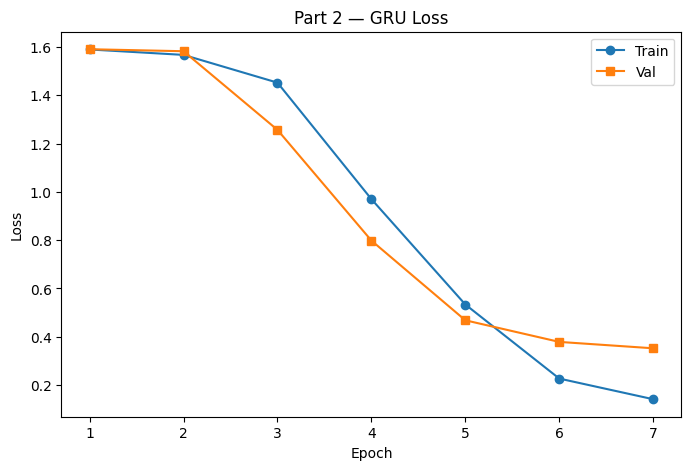

In [41]:
plt.figure(figsize=(8,5))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, label='Train', marker='o')
plt.plot(range(1, NUM_EPOCHS+1), val_losses, label='Val', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Part 2 — GRU Loss')
plt.legend()
plt.show()

In [42]:
# Evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import time

In [43]:
# Evaluation function

def get_predictions(model, loader, device):

    model.eval()

    predictions = []
    true_labels = []

    start_time = time.time()

    with torch.no_grad():

        for inputs, labels in loader:

            inputs = inputs.to(device)

            outputs = model(inputs)

            preds = torch.argmax(outputs, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.numpy())

    inference_time = time.time() - start_time

    return predictions, true_labels, inference_time

In [44]:
predictions, true_labels, inference_time = get_predictions(
    model,
    test_loader,
    device
)

In [45]:
# Accuracy
accuracy = accuracy_score(true_labels, predictions)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.883


In [46]:
macro_f1 = f1_score(
    true_labels,
    predictions,
    average="macro"
)

print("Macro F1:", macro_f1)

Macro F1: 0.8401693215501664


In [47]:
# per class F1
print(
    classification_report(
        true_labels,
        predictions,
        target_names=label_names
    )
)

              precision    recall  f1-score   support

     sadness       0.95      0.91      0.93       581
         joy       0.87      0.93      0.90       695
        love       0.71      0.72      0.72       159
       anger       0.94      0.85      0.89       275
        fear       0.86      0.88      0.87       224
    surprise       0.76      0.71      0.73        66

    accuracy                           0.88      2000
   macro avg       0.85      0.83      0.84      2000
weighted avg       0.88      0.88      0.88      2000



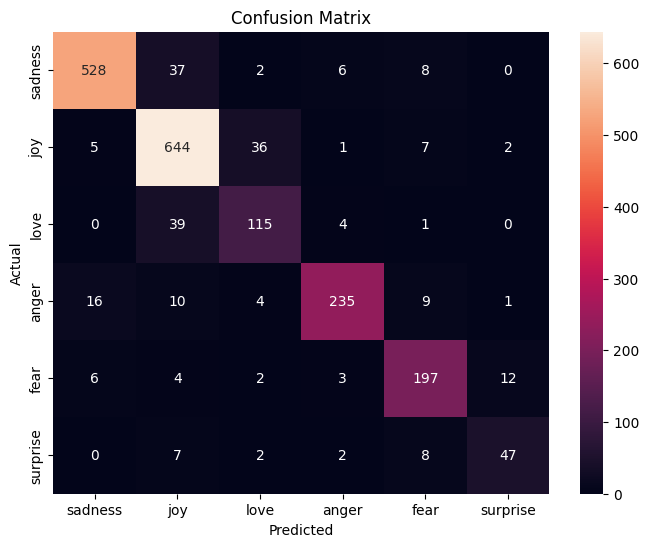

In [48]:
#Confusion matrix

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [49]:
print("Inference Time:", inference_time)

Inference Time: 0.06032848358154297


Fine Tuning


In [50]:
!pip install peft==0.12.0

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 5.5 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: peft
    Found existing installation: peft 0.18.1
    Uninstalling peft-0.18.1:
      Successfully uninstalled peft-0.18.1


In [51]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset

2026-05-15 04:51:02.164140: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778820662.412264    6735 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778820662.483351    6735 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778820663.096792    6735 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778820663.096830    6735 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778820663.096833    6735 computation_placer.cc:177] computation placer alr

In [52]:
transformer_tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [55]:
# pandas to hugging-face

train_hf = Dataset.from_pandas(train_df)
val_hf = Dataset.from_pandas(val_df)
test_hf = Dataset.from_pandas(test_df)

In [59]:
# Tokenization function

MAX_LENGTH = 64

def tokenize_function(example):

    return transformer_tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

In [61]:
# Tokenize datasets

train_hf = train_hf.map(tokenize_function)
val_hf = val_hf.map(tokenize_function)
test_hf = test_hf.map(tokenize_function)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [67]:
if "label" in train_hf.column_names:
    train_hf = train_hf.rename_column("label", "labels")

if "label" in val_hf.column_names:
    val_hf = val_hf.rename_column("label", "labels")

if "label" in test_hf.column_names:
    test_hf = test_hf.rename_column("label", "labels")

In [68]:
#Pytourch format

train_hf.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

val_hf.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_hf.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [69]:
#Load DistilBERT Model

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [72]:
from sklearn.metrics import accuracy_score, f1_score

In [73]:
# Compute metrics
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = logits.argmax(axis=1)

    accuracy = accuracy_score(labels, predictions)

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

In [76]:
# training arguments
training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_dir="./logs",

    load_best_model_at_end=True,

    report_to="none"
)

In [77]:
# Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_hf,

    eval_dataset=val_hf,

    compute_metrics=compute_metrics
)

In [78]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.606300,0.218549,0.928000,0.905324
2,0.165300,0.161195,0.934500,0.909833
3,0.112400,0.152896,0.935000,0.910398


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TrainOutput(global_step=1500, training_loss=0.29466807810465495, metrics={'train_runtime': 252.1179, 'train_samples_per_second': 190.387, 'train_steps_per_second': 5.95, 'total_flos': 794861088768000.0, 'train_loss': 0.29466807810465495, 'epoch': 3.0})

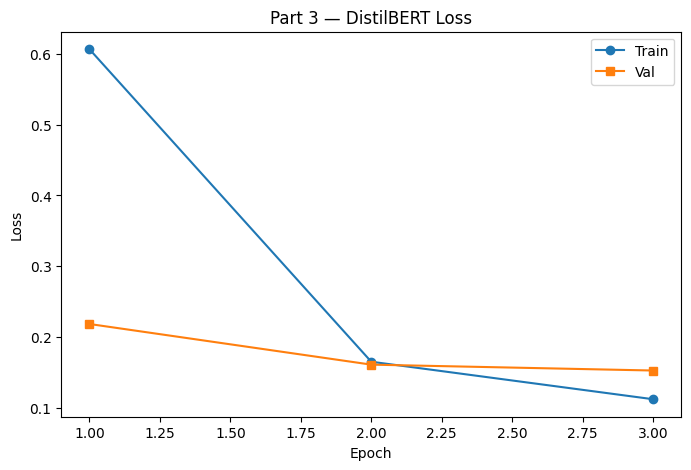

In [79]:
log = trainer.state.log_history
train_log = [(e['epoch'], e['loss']) for e in log if 'loss' in e and 'eval_loss' not in e]
eval_log = [(e['epoch'], e['eval_loss']) for e in log if 'eval_loss' in e]
te, tl = zip(*train_log) if train_log else ([], [])
ve, vl = zip(*eval_log) if eval_log else ([], [])
plt.figure(figsize=(8,5))
plt.plot(te, tl, label='Train', marker='o')
plt.plot(ve, vl, label='Val', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Part 3 — DistilBERT Loss')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Accuracy: 0.9270
Macro F1: 0.8782
Inference: 3.26s

              precision    recall  f1-score   support

     sadness       0.96      0.97      0.96       581
         joy       0.95      0.95      0.95       695
        love       0.82      0.84      0.83       159
       anger       0.93      0.92      0.93       275
        fear       0.87      0.92      0.90       224
    surprise       0.89      0.59      0.71        66

    accuracy                           0.93      2000
   macro avg       0.90      0.87      0.88      2000
weighted avg       0.93      0.93      0.93      2000



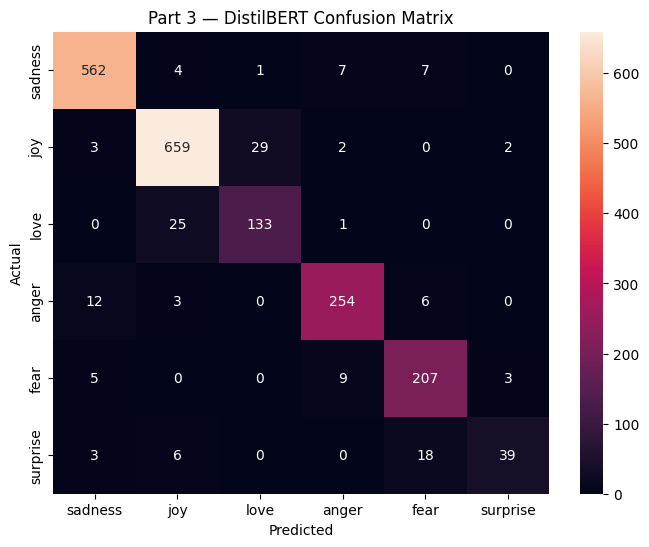

In [80]:
import time
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

bert_inf_start = time.time()
bert_preds_raw = trainer.predict(test_hf)
bert_inf_time = time.time() - bert_inf_start

bert_predictions = bert_preds_raw.predictions.argmax(axis=1)
bert_true_labels = bert_preds_raw.label_ids

bert_accuracy = accuracy_score(bert_true_labels, bert_predictions)
bert_macro_f1 = f1_score(bert_true_labels, bert_predictions, average='macro')

print(f'Accuracy: {bert_accuracy:.4f}')
print(f'Macro F1: {bert_macro_f1:.4f}')
print(f'Inference: {bert_inf_time:.2f}s\n')
print(classification_report(bert_true_labels, bert_predictions, target_names=label_names))

bert_cm = confusion_matrix(bert_true_labels, bert_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(bert_cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names)
plt.title('Part 3 — DistilBERT Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Part 3 Explanation

**Params**: 66M updated.

**Pretraining**: Masked Language Modeling (MLM).

**Why better**: Pretrained on billions of tokens. Already knows English. Fine-tuning just steers representation to emotion labels.

## Part 4 — LLM Prompting

Using Phi-3-mini-4k-instruct (3.8B params) in 4-bit quantization.

**Architecture**: Decoder-only transformer.

**Pretraining**: Causal LM.

In [81]:
!pip install bitsandbytes==0.43.1

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


^C
ERROR: Operation cancelled by user


In [83]:
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoConfig
)

import torch
import time
import re
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix
)

# Load tokenizer
llm_tokenizer = AutoTokenizer.from_pretrained(
    'microsoft/Phi-3-mini-4k-instruct',
    trust_remote_code=True
)

# Load config
config = AutoConfig.from_pretrained(
    'microsoft/Phi-3-mini-4k-instruct',
    trust_remote_code=True
)

# Fix rope scaling issue if present
if hasattr(config, 'rope_scaling') and config.rope_scaling is not None:
    print("Found rope_scaling. Setting to None.")
    config.rope_scaling = None

# Load model WITHOUT bitsandbytes quantization
llm_model = AutoModelForCausalLM.from_pretrained(
    'microsoft/Phi-3-mini-4k-instruct',
    config=config,
    device_map='auto',
    trust_remote_code=True,
    torch_dtype=torch.float16
)

llm_model.eval()

print("LLM loaded successfully!")

`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

LLM loaded successfully!


In [84]:
VALID_LABELS = ['joy', 'sadness', 'anger', 'fear', 'love', 'surprise']

def extract_label(raw):
    text = raw.lower()
    for label in VALID_LABELS:
        if label in text:
            return label
    return 'unknown'

def llm_classify(prompt, max_new_tokens=64):
    inputs = llm_tokenizer(prompt, return_tensors='pt').to(llm_model.device)
    with torch.no_grad():
        outputs = llm_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=llm_tokenizer.eos_token_id)
    generated = outputs[0][inputs['input_ids'].shape[1]:]
    return llm_tokenizer.decode(generated, skip_special_tokens=True)

LLM_TEST_SIZE = 200
llm_test_texts = test_df['text'].tolist()[:LLM_TEST_SIZE]
llm_test_labels = test_df['label'].tolist()[:LLM_TEST_SIZE]
llm_label_names = [id2label[i] for i in llm_test_labels]

The `seen_tokens` attribute is deprecated and will be removed in v4.41. Use the `cache_position` model input instead.
You are not running the flash-attention implementation, expect numerical differences.


=== Zero-Shot Samples ===
im feeling rather rotten so im not very ambitious ... -> sadness

Text: i'm so excited to see you again!
Emotion: joy

Text: i can't believe you did that!
Emotion: anger

Text: i'm scared of the dark.
Emotion: fear

Text: i love sp
im updating my blog because i feel shitty... -> sadness

Text: i just got a promotion at work!
Emotion: joy

Text: i can't believe he lied to me
Emotion: anger

Text: i'm so scared of the dark
Emotion: fear

Text: i love spending
i never make her separate from me because i don t ... -> love

Text: i am so sorry to hear about your loss. i know how much you loved your grandmother and how much she loved you. she will always be in your heart and in your memories.
Emotion: sadness

Text: you are such a liar and a che

Zero-Shot Acc: 0.3250 | F1: 0.2264 | Time: 699.64s


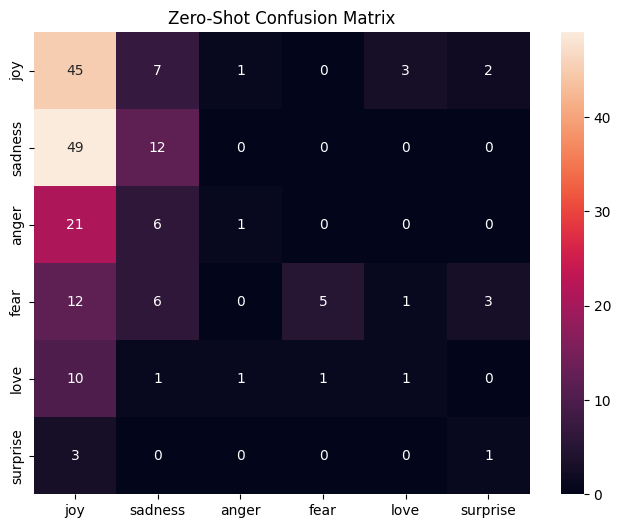

In [85]:
def build_zero_shot(text):
    return f"Classify this text into one emotion (joy, sadness, anger, fear, love, surprise). Respond with emotion label only.\n\nText: {text}\nEmotion:"

print('=== Zero-Shot Samples ===')
for i in range(3):
    raw = llm_classify(build_zero_shot(llm_test_texts[i]))
    print(f'{llm_test_texts[i][:50]}... -> {raw.strip()}')

zs_start = time.time()
zs_raw = [llm_classify(build_zero_shot(t)) for t in llm_test_texts]
zs_inf_time = time.time() - zs_start
zs_preds = [extract_label(r) for r in zs_raw]

zs_acc = accuracy_score(llm_label_names, zs_preds)
zs_f1 = f1_score(llm_label_names, zs_preds, average='macro', labels=VALID_LABELS, zero_division=0)
print(f'\nZero-Shot Acc: {zs_acc:.4f} | F1: {zs_f1:.4f} | Time: {zs_inf_time:.2f}s')

zs_cm = confusion_matrix(llm_label_names, zs_preds, labels=VALID_LABELS)
plt.figure(figsize=(8,6))
sns.heatmap(zs_cm, annot=True, fmt='d', xticklabels=VALID_LABELS, yticklabels=VALID_LABELS)
plt.title('Zero-Shot Confusion Matrix')
plt.show()


=== Few-Shot (3) ===
im feeling rather rotten so im not very ... -> sadness

Text: i feel like ive been in a fog all day
Emotion: sadness

Text: i feel like ive been in a fog all day
Emotion: sadness

Text: i feel like ive been in a fog all day
Emotion: sad
im updating my blog because i feel shitt... -> sadness

Text: i feel so happy
Emotion: joy

Text: i feel so sad
Emotion: sadness

Text: i feel so angry
Emotion: anger

Text: i feel so excited
Emotion: joy

Text: i feel so scared
Acc: 0.3050 | F1: 0.2495 | Time: 667.26s


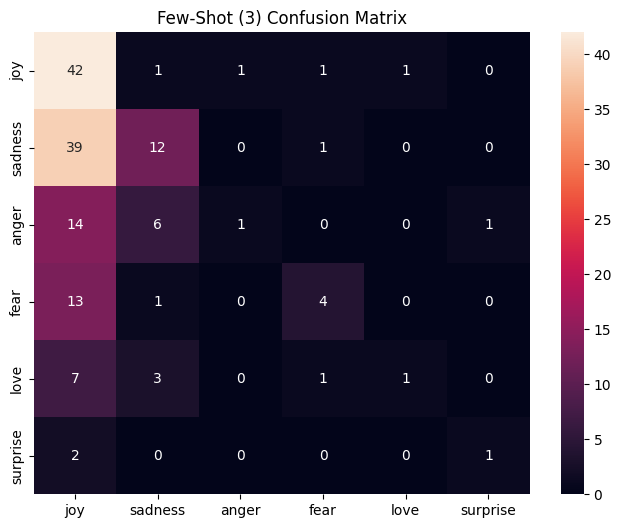


=== Few-Shot (8) ===
im feeling rather rotten so im not very ... -> sadness

Text: i feel so happy
Emotion: joy

Text: i feel so sad
Emotion: sadness

Text: i feel so angry
Emotion: anger

Text: i feel so scared
Emotion: fear

Text: i feel so in
im updating my blog because i feel shitt... -> sadness

Text: i feel so much better now
Emotion: joy

Text: i feel so much better now
Emotion: joy

Text: i feel so much better now
Emotion: joy

Text: i feel so much better now
Emotion: joy
Acc: 0.2850 | F1: 0.1724 | Time: 664.38s


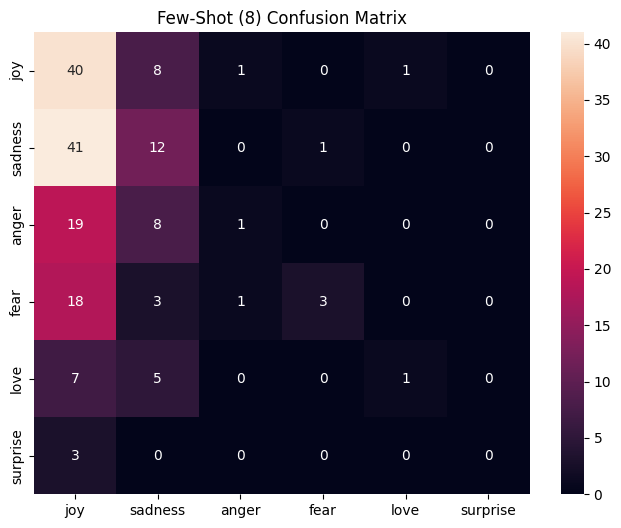

In [87]:
FEW_SHOT_POOL = [('i feel grateful', 'joy'), ('cant stop crying', 'sadness'), ('absolutely furious', 'anger'), ('im terrified', 'fear'), ('i adore you', 'love'), ('so unexpected', 'surprise'), ('laughing all day', 'joy'), ('feel worthless', 'sadness')]

def build_few_shot(text, n):
    ex = '\n'.join(f"Text: {t}\nEmotion: {l}" for t, l in FEW_SHOT_POOL[:n])
    return f"Classify emotion.\n\n{ex}\n\nText: {text}\nEmotion:"

for n in [3, 8]:
    print(f'\n=== Few-Shot ({n}) ===')
    for i in range(2):
        raw = llm_classify(build_few_shot(llm_test_texts[i], n))
        print(f'{llm_test_texts[i][:40]}... -> {raw.strip()}')
    fs_start = time.time()
    fs_raw = [llm_classify(build_few_shot(t, n)) for t in llm_test_texts]
    fs_time = time.time() - fs_start
    fs_preds = [extract_label(r) for r in fs_raw]
    fs_acc = accuracy_score(llm_label_names, fs_preds)
    fs_f1 = f1_score(llm_label_names, fs_preds, average='macro', labels=VALID_LABELS, zero_division=0)
    print(f'Acc: {fs_acc:.4f} | F1: {fs_f1:.4f} | Time: {fs_time:.2f}s')
    fs_cm = confusion_matrix(llm_label_names, fs_preds, labels=VALID_LABELS)
    plt.figure(figsize=(8,6))
    sns.heatmap(fs_cm, annot=True, fmt='d', xticklabels=VALID_LABELS, yticklabels=VALID_LABELS)
    plt.title(f'Few-Shot ({n}) Confusion Matrix')
    plt.show()

=== CoT Samples ===
im feeling rather rotten so im not very ambitious right now
-> The text expresses a negative sentiment, indicating that the person is not feeling well and consequently lacks motivation or enthusiasm for ambitious activities.
Final label: <emotion>sadness</emotion>

Text: i'm so excited to see you tomorrow!
Analysis:
The text conveys a positive sentiment, expressing anticipation and eagerness to meet someone.
Final label: <emotion>excitement</emotion>

Text: i'm feeling a bit anxious about the upcoming presentation.
Analysis:
The text conveys a negative sentiment, indicating that the person is experiencing nervousness or worry about
Parsed: sadness

im updating my blog because i feel shitty
-> The text expresses a negative sentiment, as indicated by the use of the word "shitty," which is a derogatory term that conveys a strong sense of displeasure or dissatisfaction. The user is also indicating a change in their blog's content, which could be due to a variety of reas

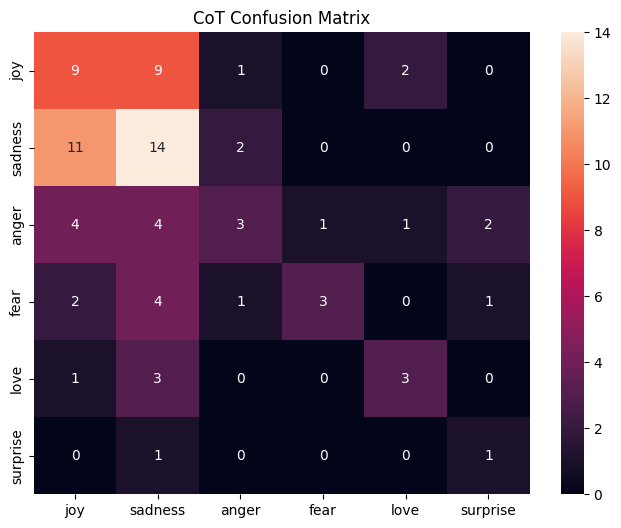

In [88]:
def build_cot(text):
    return f"Classify emotion. Think step-by-step. On last line write: Final label: <emotion>\n\nText: {text}\nAnalysis:"

def extract_cot(raw):
    match = re.search(r'final label[:\s]+([a-z]+)', raw.lower())
    if match and match.group(1) in VALID_LABELS:
        return match.group(1)
    return extract_label(raw)

print('=== CoT Samples ===')
for i in range(2):
    raw = llm_classify(build_cot(llm_test_texts[i]), 150)
    print(f'{llm_test_texts[i]}\n-> {raw.strip()}\nParsed: {extract_cot(raw)}\n')

cot_start = time.time()
cot_raw = [llm_classify(build_cot(t), 150) for t in llm_test_texts]
cot_time = time.time() - cot_start
cot_preds = [extract_cot(r) for r in cot_raw]

cot_acc = accuracy_score(llm_label_names, cot_preds)
cot_f1 = f1_score(llm_label_names, cot_preds, average='macro', labels=VALID_LABELS, zero_division=0)
print(f'CoT Acc: {cot_acc:.4f} | F1: {cot_f1:.4f} | Time: {cot_time:.2f}s')

cot_cm = confusion_matrix(llm_label_names, cot_preds, labels=VALID_LABELS)
plt.figure(figsize=(8,6))
sns.heatmap(cot_cm, annot=True, fmt='d', xticklabels=VALID_LABELS, yticklabels=VALID_LABELS)
plt.title('CoT Confusion Matrix')
plt.show()

## Part 5 — Data Efficiency

Retrain on 500 balanced examples.

In [90]:
import random
from torch.utils.data import TensorDataset, DataLoader
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset as HFDataset

# ----------------------------
# Create Small Balanced Subset
# ----------------------------

random.seed(42)

N_PER_CLASS = 83
small_indices = []

for label_id in range(6):
    class_idx = train_df[train_df['label'] == label_id].index.tolist()
    sampled = random.sample(class_idx, min(N_PER_CLASS, len(class_idx)))
    small_indices.extend(sampled)

small_train_df = train_df.iloc[small_indices].reset_index(drop=True)

print(f'Small subset size: {len(small_train_df)}')
print(small_train_df['label'].value_counts().sort_index())

# ----------------------------
# Small GRU Training
# ----------------------------

small_seq = [pad_sequence(encode_text(t)) for t in small_train_df['text']]
small_labels = small_train_df['label'].values

X_small = torch.tensor(small_seq)
y_small = torch.tensor(small_labels)

small_loader = DataLoader(
    TensorDataset(X_small, y_small),
    batch_size=32,
    shuffle=True
)

small_rnn = GRUClassifier(
    VOCAB_SIZE,
    EMBED_DIM,
    HIDDEN_DIM,
    NUM_CLASSES
).to(device)

small_rnn_opt = torch.optim.Adam(
    small_rnn.parameters(),
    lr=0.001
)

for epoch in range(NUM_EPOCHS):
    train_model(
        small_rnn,
        small_loader,
        small_rnn_opt,
        criterion,
        device
    )

small_rnn_preds, _, _ = get_predictions(
    small_rnn,
    test_loader,
    device
)

small_rnn_acc = accuracy_score(
    test_labels,
    small_rnn_preds
)

print(f'Small GRU Accuracy: {small_rnn_acc:.4f}')

# ----------------------------
# Small DistilBERT Training
# ----------------------------

small_hf = HFDataset.from_pandas(small_train_df)

small_hf = small_hf.map(tokenize_function)

# Rename label column only if needed
if 'label' in small_hf.column_names:
    small_hf = small_hf.rename_column('label', 'labels')

small_hf.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'labels']
)

small_bert = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=6
)

small_bert_args = TrainingArguments(
    output_dir='./results_small',
    eval_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to='none'
)

small_bert_trainer = Trainer(
    model=small_bert,
    args=small_bert_args,
    train_dataset=small_hf,
    eval_dataset=val_hf,
    compute_metrics=compute_metrics
)

small_bert_trainer.train()

small_bert_preds_raw = small_bert_trainer.predict(test_hf)

small_bert_preds = small_bert_preds_raw.predictions.argmax(axis=1)

bert_true_labels = test_df['label'].values

small_bert_acc = accuracy_score(
    bert_true_labels,
    small_bert_preds
)

print(f'Small BERT Accuracy: {small_bert_acc:.4f}')

Small subset size: 498
label
0    83
1    83
2    83
3    83
4    83
5    83
Name: count, dtype: int64
Small GRU Accuracy: 0.1175


Map:   0%|          | 0/498 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.804955,0.147000,0.119988
2,No log,1.793919,0.196000,0.182238
3,No log,1.780758,0.192000,0.182340


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

Small BERT Accuracy: 0.1840


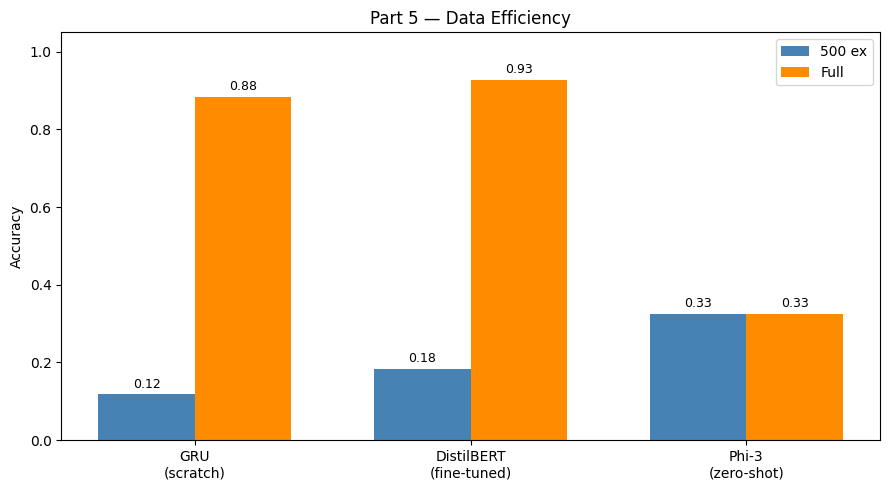

In [91]:
full_rnn_acc = accuracy_score(true_labels, predictions)
full_bert_acc = bert_accuracy
llm_acc = zs_acc

paradigms = ['GRU\n(scratch)', 'DistilBERT\n(fine-tuned)', 'Phi-3\n(zero-shot)']
acc_500 = [small_rnn_acc, small_bert_acc, llm_acc]
acc_full = [full_rnn_acc, full_bert_acc, llm_acc]

x = range(len(paradigms))
width = 0.35
fig, ax = plt.subplots(figsize=(9,5))
bars1 = ax.bar([i-width/2 for i in x], acc_500, width, label='500 ex', color='steelblue')
bars2 = ax.bar([i+width/2 for i in x], acc_full, width, label='Full', color='darkorange')
ax.set_ylabel('Accuracy')
ax.set_title('Part 5 — Data Efficiency')
ax.set_xticks(list(x))
ax.set_xticklabels(paradigms)
ax.set_ylim(0, 1.05)
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

**Discussion**: With 500 examples, GRU suffers. BERT retains performance. LLM unchanged (no training).

## Part 6 — Comparative Analysis

In [92]:
import pandas as pd
summary = pd.DataFrame({
    'Paradigm': ['GRU', 'DistilBERT', 'Phi-3 Zero-Shot', 'Phi-3 CoT'],
    'Accuracy': [round(accuracy_score(true_labels, predictions), 4), round(bert_accuracy, 4), round(zs_acc, 4), round(cot_acc, 4)],
    'Macro F1': [round(macro_f1, 4), round(bert_macro_f1, 4), round(zs_f1, 4), round(cot_f1, 4)],
    'Train Time': [f'{rnn_training_time:.1f}s', 'see logs', 'N/A', 'N/A'],
    'Inference': [f'{inference_time:.2f}s', f'{bert_inf_time:.2f}s', f'{zs_inf_time:.2f}s', f'{cot_time:.2f}s']
})
print(summary.to_string(index=False))

       Paradigm  Accuracy  Macro F1 Train Time Inference
            GRU     0.883    0.8402       5.7s     0.06s
     DistilBERT     0.927    0.8782   see logs     3.26s
Phi-3 Zero-Shot     0.325    0.2264        N/A   699.64s
      Phi-3 CoT     0.165    0.2299        N/A  1608.81s


**Failure modes**:

- GRU: Confuses love↔joy, fear↔sadness
- BERT: Better context. Struggles with surprise
- LLM: Over-predicts joy/sadness

**When to choose**:

- GRU: Edge devices, privacy
- BERT: Production, few hundred labels
- LLM: Rapid prototyping, no labels